# 11. Time series tool for analysing HDF5/pandas files 

### Setup notebook

In [2]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [11]:
import os
import glob
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from zipfile import ZipFile

# PlatoSim
import platosim.plot as pt
import platosim.utilities as ut
import platosim.referenceFrames as rf
from platosim.photometryfile import PhotometryFile
from platosim.matplotlibrc import setup
setup()

### Run a default simulation for the tutorial

In [3]:
outputDir      = os.getcwd()
outputFile     = f"{outputDir}/{outputFileName}.hdf5"

---

##  Basic overview

We have alread touched upon how you can use the `SimFile` class to retrieve information from the HDF5 file. Here we dive in a bit deeper and show several functionalites. We will look at the following APIs:

In [139]:
# Read path
path = '/lhome/nicholas/sims_kul21/jitterNone/000000001/' 

# Fetch all zip files
files = glob.glob(path+ "*.zip")

# Unpack zip files
with ZipFile(files[0], 'r') as unzip:
    unzip.extractall(path)
    
# Get file names
filename_ftr = files[0][:-3] + "ftr"
filename_cat = files[0][:-3] + "cat"

let's start by a simple example of extracting the simulated light curve and plotting a 1 hour binned curve on top which is the general time scale used in the PLATO mission for noise subpression of finding exoplanets.

In [140]:
# Load feather file
lc = PhotometryFile(filename_ftr)

In [141]:
# Get obs information; [group, camera, quarter] 
lc.obs()

(1, 6, 2)

<IPython.core.display.Javascript object>


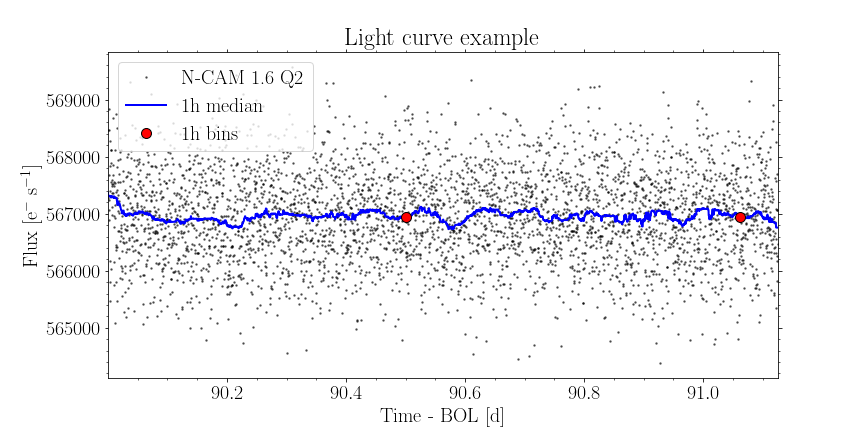

In [144]:
# Create a plot of 
fig, ax = lc.plot(flux_unit="e/s", errorbar=False, median_filter=True, binsize=1)
ax.set_title('Light curve example');

It is straight away to fetch the rebinned light curve shown above a red markers:

In [33]:
time_bin, flux_bin, tdur_bin = lc.bin(unit="ppm")
flux_bin

array([ 169.00313461,   27.82672816, -130.4545866 , -142.80446599,
       -112.69792823,   33.20207116,   -2.97230545,  -67.37215294,
         -1.61522338,   40.85838676,    4.45758947,   51.07946211,
        126.51925321,  -48.78819417, -123.05079704,   89.90048037,
        167.63428246,   37.37665336,  -14.06551234,  235.87962479,
        -60.42590898, -164.44182619,  -47.7628951 ,  -84.6492869 ,
          2.41915727,    6.31868502,    2.78272432])

## Photometric precision

To analyse the noise level in a ligth curve a few options are available. The first is the Noise-to-Signal Ratio (NSR) defined by:

$$
{\rm NSR}_{\rm 1h} = \frac{10^6}{\sqrt{144}}\frac{\sigma_F}{\bar{F}}
$$

In [18]:
lc.getNSR()

116.86962468636929

It is easy to get the Root-Mean-Square of the noise level in a light curve defined by

$$
{\rm RMS}_{\rm 1h} = \frac{10^6}{\sqrt{144}}\frac{F_{\rm median}}{\bar{F}}
$$

In [27]:
# Fetch NSR [ppm/sqrt(h)]
lc.getRMS(column="flux_med", unit="ppm")

117.4662799939503

Lastly the Median Absolute Deviation (MAD) can also be fetched by:

In [25]:
lc.getMAD(column="flux_med", unit="ppm")

117.4662799939503

In [37]:
# Mean flux error in percent
flux     = lc.flux()
flux_err = lc.flux_err()
flux_err_percent = flux_err.mean() / flux.mean() * 100
flux_err_percent

0.14173416775143954

In [38]:
# Mean centroid error in percent
xcen = lc.xcen(unit="pix")
ycen = lc.ycen(unit="pix")
xcen_err = lc.xcen_err(unit="pix")
ycen_err = lc.ycen_err(unit="pix")
rcen     = np.sqrt(xcen**2 + ycen**2)
rcen_err = np.sqrt(xcen_err**2 + ycen_err**2)
rcen_err_percent = rcen_err.mean() / rcen.mean() * 100
rcen_err_percent

0.03064183328247153

In [39]:
lc.time()
# phot.flux_err()
# xcen =phot.xcen(unit="rel")
# phot.xcen_err(unit="pix")
# ycen = phot.ycen(unit="rel")
# phot.xcen_err(unit="pix")

0       90.000145
1       90.000434
2       90.000723
3       90.001013
4       90.001302
          ...    
3883    91.123698
3884    91.123987
3885    91.124277
3886    91.124566
3887    91.124855
Name: time, Length: 3888, dtype: float64

### Centroid and jitter

<IPython.core.display.Javascript object>


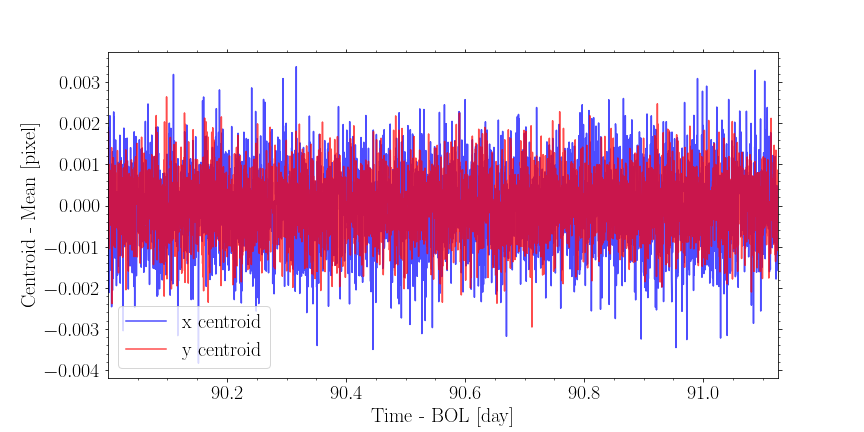

0.0006022984374285536

In [40]:
lc.plotCentroid(cen_unit="rel");


In [ ]:
xcen = dc["x"][0] - 3.5
ycen = dc["y"][0] - 3.5
rcen = np.sqrt(xcen**2 + ycen**2)
rcen

---

## Multi-camera photometry

In [135]:
# Load all feather files
path = '/lhome/nicholas/sims_kul21/jitterNone/000000001/' 
lc = PhotometryFile(path, mode="multi")

In [136]:
# Unpack all zip files in the path folder
lc.unpack()

In [137]:
# Merge all observations for the same quarter 
lc1, ncam = lc.merge(quarter=1)
ncam

12

In [138]:
binned = lc1.bin()
binned.head()

,time,flux,flux_err,sigma
0,0.499964,2.668080,1.293173,1363.971008
1,1.062391,-21.525713,-10.379054,1349.435539


<IPython.core.display.Javascript object>


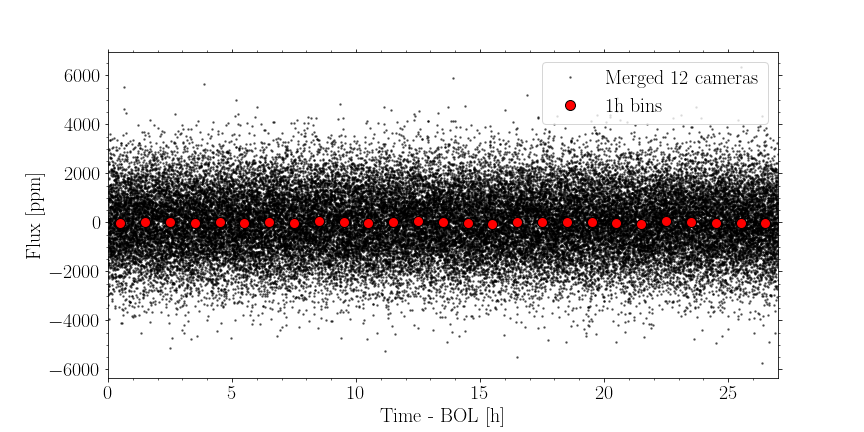

In [134]:
# We can also plot the binned data directly along the merged light curve
fig, ax = lc1.plot(time_unit="h", binsize=1, merged=ncam);